# Forward PINN for Darcy Flow Below a Reservoir

Goal: build a **forward Physics-Informed Neural Network** for the hydraulic head field `h(x, y)`.

Important distinction:

- The Excel files are useful for **visualizing the problem** and later checking your result.
- The forward PINN loss should use **only the PDE and boundary conditions**, not the measured/generated head values.

This notebook is intentionally written as a scaffold. Some PyTorch pieces are left as `TODO` so you can implement the model yourself.


## 0. Imports

Use `numpy/pandas/matplotlib` for data inspection and plotting. Use `torch` later for automatic differentiation.


In [19]:
# If needed, install once:
%pip install -q numpy pandas matplotlib openpyxl torch


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True


## 1. Choose a Case and Inspect the Provided Data

The filename pattern is:

```text
h1_h2_hd.xlsx
```

where:

- `h1` is the reservoir head,
- `h2` is the downstream catchment head,
- `hd` is the embedded wall depth.

For a forward PINN, we do **not** train on `FINIT`; here we only inspect it so we understand the geometry and have something to compare with after training.


In [21]:
# This path assumes the notebook is opened from the Code/ folder.
# If your kernel starts from the project root, use: "Data/heads/20_5_25.xlsx"
data_path = "../Data/heads/20_5_25.xlsx"

h1, h2, hd = map(float, data_path.split("/")[-1].replace(".xlsx", "").split("_"))
df = pd.read_excel(data_path).dropna()

print(f"case: h1={h1:g} m, h2={h2:g} m, hd={hd:g} m")
print(df.head())
print(df[["X", "Y", "FINIT"]].describe())


case: h1=20 m, h2=5 m, hd=25 m
   ID          X    Y  Node      FINIT FINIT_U
0   1   0.000000  0.0     1  19.825926       m
1   2   3.571429  0.0     2  19.824307       m
2   3   7.142857  0.0     3  19.819018       m
3   4  10.714286  0.0     4  19.810251       m
4   5  14.285714  0.0     5  19.797800       m
                X           Y       FINIT
count  573.000000  573.000000  573.000000
mean    71.615152   19.280380   16.365533
std     44.260656   12.308220    5.065581
min      0.000000    0.000000    5.000000
25%     32.142857    9.208183   13.487024
50%     67.890332   18.658239   19.335246
75%    107.876001   29.826181   19.812254
max    150.000000   40.000000   20.000000


## 2. Plot the Reference Head Data

Again: this is **not training data** for the forward PINN. It is a useful reference plot so you can later judge whether the physics-only solution has the correct shape.


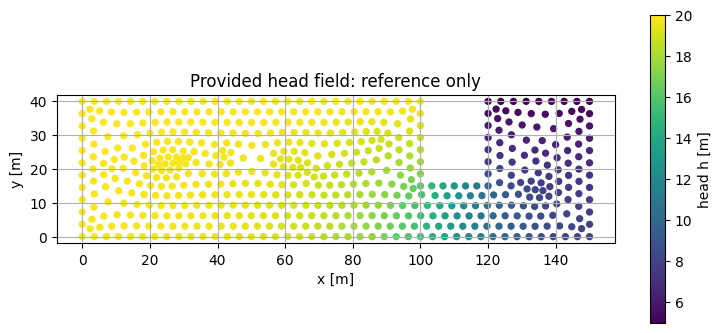

In [22]:
fig, ax = plt.subplots(figsize=(9, 4))
sc = ax.scatter(df["X"], df["Y"], c=df["FINIT"], s=18, cmap="viridis")
fig.colorbar(sc, ax=ax, label="head h [m]")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title("Provided head field: reference only")
ax.set_aspect("equal", adjustable="box")
plt.show()


## 3. Nondimensionalize the Governing Equation

The dimensional PDE is Laplace's equation:

$$
\Delta h = \frac{\partial^2 h}{\partial x^2} + \frac{\partial^2 h}{\partial y^2} = 0.
$$

Choose one length scale, for example the total horizontal length:

$$
L = 150\;\text{m}.
$$

Define dimensionless coordinates and head:

$$
\hat{x}=\frac{x}{L}, \qquad \hat{y}=\frac{y}{L}, \qquad
H = \frac{h-h_2}{h_1-h_2}.
$$

Then:

$$
h = h_2 + (h_1-h_2)H.
$$

Because `h2` and `(h1-h2)` are constants, the PDE becomes:

$$
\frac{\partial^2 H}{\partial \hat{x}^2} +
\frac{\partial^2 H}{\partial \hat{y}^2}=0.
$$

Boundary heads become simple:

$$
H=1 \quad \text{on the reservoir boundary},
$$

$$
H=0 \quad \text{on the downstream catchment boundary}.
$$

Impermeable boundaries satisfy no-flow, so the normal derivative is zero:

$$
\nabla H \cdot n = 0.
$$


In [23]:
L = 150.0      # length scale [m]
D = 40.0       # aquifer thickness [m]
x_res = 100.0  # reservoir ends at x=100 m
x_dam = 120.0  # dam/catchment starts at x=120 m
x_wall = 100.0 # embedded vertical wall location
kf = 1.0       # hydraulic conductivity [m/day]

def to_hat_xy(xy):
    """Convert dimensional coordinates [m] to nondimensional coordinates."""
    return xy / L

def from_hat_head(H):
    """Convert nondimensional head H back to dimensional head h [m]."""
    return h2 + (h1 - h2) * H

print("Domain in nondimensional coordinates:")
print(f"x_hat in [0, {L/L:.3f}]")
print(f"y_hat in [0, {D/L:.3f}]")
print(f"wall from y={(D-hd):.1f} m to y={D:.1f} m")


Domain in nondimensional coordinates:
x_hat in [0, 1.000]
y_hat in [0, 0.267]
wall from y=15.0 m to y=40.0 m


## 4. Draw the Domain and Boundary Conditions

This plot is the checklist for your loss terms.

Suggested boundary conditions:

- Top-left reservoir surface: `H = 1`
- Top-right catchment surface: `H = 0`
- Bottom bedrock: `dH/dy = 0`
- Left and right vertical boundaries: `dH/dx = 0`
- Dam top/foundation between reservoir and catchment: `dH/dy = 0`
- Embedded vertical wall: `dH/dx = 0` on both sides


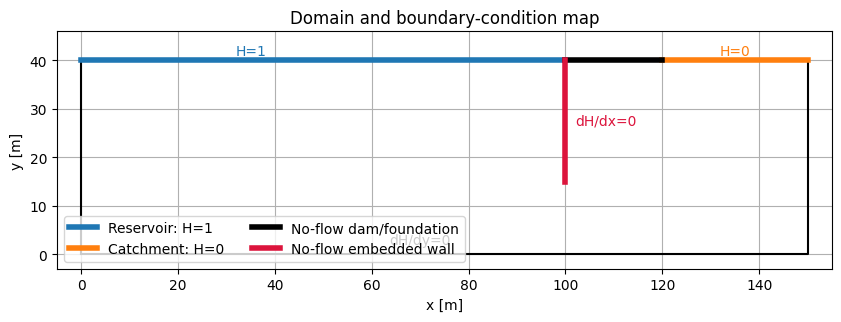

In [24]:
fig, ax = plt.subplots(figsize=(10, 4))

# Domain box
ax.plot([0, L, L, 0, 0], [0, 0, D, D, 0], color="black", lw=1.5)

# Dirichlet boundaries
ax.plot([0, x_res], [D, D], color="tab:blue", lw=4, label="Reservoir: H=1")
ax.plot([x_dam, L], [D, D], color="tab:orange", lw=4, label="Catchment: H=0")

# Impermeable dam top and embedded wall
ax.plot([x_res, x_dam], [D, D], color="black", lw=4, label="No-flow dam/foundation")
ax.plot([x_wall, x_wall], [D - hd, D], color="crimson", lw=4, label="No-flow embedded wall")

ax.text(35, D + 1.2, "H=1", color="tab:blue", ha="center")
ax.text(135, D + 1.2, "H=0", color="tab:orange", ha="center")
ax.text(x_wall + 2, D - hd / 2, "dH/dx=0", color="crimson", va="center")
ax.text(70, 2, "dH/dy=0", color="black", ha="center")

ax.set_xlim(-5, L + 5)
ax.set_ylim(-3, D + 6)
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="lower left", ncols=2)
ax.set_title("Domain and boundary-condition map")
plt.show()


## 5. Sample Collocation and Boundary Points

The PINN needs points where each loss is evaluated:

- Interior collocation points for the PDE residual
- Boundary points for Dirichlet constraints
- Boundary points for Neumann/no-flow constraints

The code below samples points and plots them. You can improve the sampler later, for example by adding extra points near the embedded wall tip where the solution changes quickly.


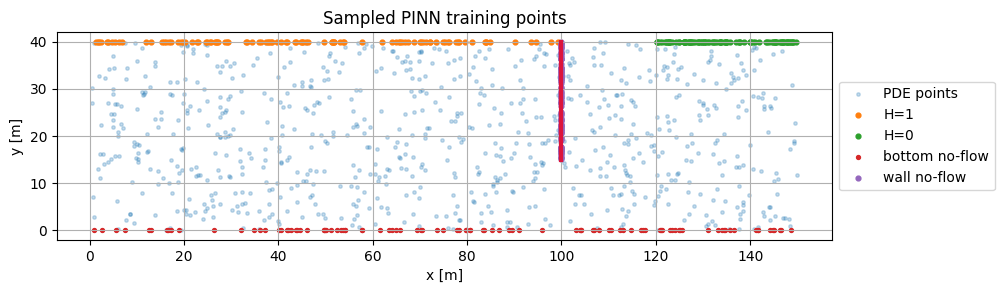

In [25]:
rng = np.random.default_rng(7)

def sample_interior(n):
    x = rng.uniform(0, L, n)
    y = rng.uniform(0, D, n)
    return np.column_stack([x, y])

def sample_boundaries(n):
    reservoir = np.column_stack([rng.uniform(0, x_res, n), D * np.ones(n)])
    catchment = np.column_stack([rng.uniform(x_dam, L, n), D * np.ones(n)])
    bottom = np.column_stack([rng.uniform(0, L, n), np.zeros(n)])
    left = np.column_stack([np.zeros(n), rng.uniform(0, D, n)])
    right = np.column_stack([L * np.ones(n), rng.uniform(0, D, n)])
    dam_top = np.column_stack([rng.uniform(x_res, x_dam, n), D * np.ones(n)])
    wall = np.column_stack([x_wall * np.ones(n), rng.uniform(D - hd, D, n)])

    return {
        "reservoir": reservoir,
        "catchment": catchment,
        "bottom": bottom,
        "left": left,
        "right": right,
        "dam_top": dam_top,
        "wall": wall,
    }

xy_int = sample_interior(800)
bc = sample_boundaries(100)

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(xy_int[:, 0], xy_int[:, 1], s=6, alpha=0.25, label="PDE points")
ax.scatter(bc["reservoir"][:, 0], bc["reservoir"][:, 1], s=12, label="H=1")
ax.scatter(bc["catchment"][:, 0], bc["catchment"][:, 1], s=12, label="H=0")
ax.scatter(bc["bottom"][:, 0], bc["bottom"][:, 1], s=8, label="bottom no-flow")
ax.scatter(bc["wall"][:, 0], bc["wall"][:, 1], s=12, label="wall no-flow")
ax.plot([x_wall, x_wall], [D-hd, D], color="crimson", lw=3)
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
ax.set_title("Sampled PINN training points")
plt.show()


## 6. Plan the PINN Loss

Your model receives nondimensional coordinates and predicts nondimensional head:

$$
(\hat{x}, \hat{y}) \mapsto H_\theta(\hat{x}, \hat{y}).
$$

The total loss can be:

$$
\mathcal{L} = \mathcal{L}_{PDE} + \lambda_D \mathcal{L}_{D} + \lambda_N \mathcal{L}_{N}.
$$

PDE loss:

$$
\mathcal{L}_{PDE} = \text{MSE}\left(
\frac{\partial^2 H_\theta}{\partial \hat{x}^2} +
\frac{\partial^2 H_\theta}{\partial \hat{y}^2}, 0
\right).
$$

Dirichlet loss:

$$
\mathcal{L}_{D}=\text{MSE}(H_\theta, 1)_{reservoir}
+\text{MSE}(H_\theta, 0)_{catchment}.
$$

Neumann/no-flow loss:

$$
\mathcal{L}_{N}=\text{MSE}(\nabla H_\theta \cdot n, 0)_{impermeable}.
$$


## 7. PyTorch Setup: You Fill in the Network

Start simple: an MLP with `Tanh` activations usually works well for PINNs.

Suggested architecture:

```text
input:  (x_hat, y_hat)
width:  32 or 64
layers: 4 to 6 hidden layers
output: H_hat
```

Implementation hints:

- Convert sampled numpy arrays to `torch.float32` tensors.
- Use `requires_grad_(True)` on coordinates when computing derivatives.
- Use `torch.autograd.grad(..., create_graph=True)` for first and second derivatives.


In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# TODO: implement your neural network.
# Start with a small MLP using nn.Linear and nn.Tanh.

class HeadPINN(nn.Module):
    def __init__(self):
        super().__init__()
        # Example structure, but fill in the exact layers yourself:
        # self.net = nn.Sequential(...)
        pass

    def forward(self, xy_hat):
        # return self.net(xy_hat)
        raise NotImplementedError


cpu


## 8. Autograd Helpers

This is the key PINN trick. You need derivatives of the network output with respect to its input coordinates.

Fill in the missing pieces after you define the model.


In [27]:
def torch_xy(xy_np):
    xy_hat_np = xy_np / L
    return torch.tensor(xy_hat_np, dtype=torch.float32, device=device)

def grad(outputs, inputs):
    # TODO: compute derivative of outputs with respect to inputs.
    # Hint: use torch.autograd.grad with create_graph=True.
    raise NotImplementedError

def laplace_residual(model, xy_hat):
    xy_hat = xy_hat.clone().detach().requires_grad_(True)
    H = model(xy_hat)

    # TODO:
    # grad_H = grad(H, xy_hat)
    # H_x = grad_H[:, 0:1]
    # H_y = grad_H[:, 1:2]
    # H_xx = ...
    # H_yy = ...
    # return H_xx + H_yy
    raise NotImplementedError

def normal_derivative(model, xy_hat, component):
    xy_hat = xy_hat.clone().detach().requires_grad_(True)
    H = model(xy_hat)

    # TODO: compute grad(H) and select component 0 or 1.
    raise NotImplementedError


## 9. Build One Training Step

Do this before writing a long training loop. A single step should:

1. Sample points.
2. Convert them to torch tensors.
3. Compute PDE, Dirichlet, and Neumann losses.
4. Combine them.
5. Backpropagate and update the model.

Weights such as `lambda_D = 20` and `lambda_N = 5` are starting points, not sacred constants.


In [28]:
# TODO: uncomment and complete this after implementing HeadPINN and the derivative helpers.

# model = HeadPINN().to(device)
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
# lambda_D = 20.0
# lambda_N = 5.0

# def training_step(n_int=2048, n_bc=256):
#     model.train()
#     optimizer.zero_grad()
#
#     xy_int = torch_xy(sample_interior(n_int))
#     bc_np = sample_boundaries(n_bc)
#
#     pde = laplace_residual(model, xy_int)
#     loss_pde = torch.mean(pde**2)
#
#     H_res = model(torch_xy(bc_np["reservoir"]))
#     H_cat = model(torch_xy(bc_np["catchment"]))
#     loss_D = torch.mean((H_res - 1.0)**2) + torch.mean(H_cat**2)
#
#     # Neumann examples:
#     # bottom: dH/dy_hat = 0
#     # wall:   dH/dx_hat = 0
#     dH_bottom = normal_derivative(model, torch_xy(bc_np["bottom"]), component=1)
#     dH_wall = normal_derivative(model, torch_xy(bc_np["wall"]), component=0)
#
#     # TODO: add left, right, and dam_top terms too.
#     loss_N = torch.mean(dH_bottom**2) + torch.mean(dH_wall**2)
#
#     loss = loss_pde + lambda_D * loss_D + lambda_N * loss_N
#     loss.backward()
#     optimizer.step()
#
#     return {
#         "total": float(loss.detach().cpu()),
#         "pde": float(loss_pde.detach().cpu()),
#         "dirichlet": float(loss_D.detach().cpu()),
#         "neumann": float(loss_N.detach().cpu()),
#     }


## 10. Training Loop and Loss Plot

Once one training step works, run the loop and plot the losses. If one loss term dominates, tune `lambda_D`, `lambda_N`, the sample counts, or the learning rate.


In [29]:
# TODO: run after training_step is complete.

# history = []
# for epoch in range(1, 3001):
#     logs = training_step()
#     history.append(logs)
#
#     if epoch == 1 or epoch % 300 == 0:
#         print(epoch, logs)
#
# hist = pd.DataFrame(history)
# ax = hist.plot(logy=True, figsize=(8, 4))
# ax.set_xlabel("epoch")
# ax.set_ylabel("loss")
# ax.set_title("PINN training losses")
# plt.show()


## 11. Plot the Learned Head Field

After training, evaluate the model on a grid, convert `H` back to dimensional `h`, and draw contours.


In [30]:
# TODO: run after model is trained.

# nx, ny = 160, 70
# xs = np.linspace(0, L, nx)
# ys = np.linspace(0, D, ny)
# X, Y = np.meshgrid(xs, ys)
# grid_xy = np.column_stack([X.ravel(), Y.ravel()])
#
# model.eval()
# with torch.no_grad():
#     H_pred = model(torch_xy(grid_xy)).cpu().numpy().reshape(ny, nx)
# h_pred = from_hat_head(H_pred)
#
# fig, ax = plt.subplots(figsize=(10, 4))
# cf = ax.contourf(X, Y, h_pred, levels=40, cmap="viridis")
# ax.contour(X, Y, h_pred, levels=12, colors="white", alpha=0.5, linewidths=0.7)
# ax.plot([x_wall, x_wall], [D-hd, D], color="crimson", lw=3)
# ax.plot([x_res, x_dam], [D, D], color="black", lw=3)
# fig.colorbar(cf, ax=ax, label="predicted head h [m]")
# ax.set_xlabel("x [m]")
# ax.set_ylabel("y [m]")
# ax.set_aspect("equal", adjustable="box")
# ax.set_title("PINN-predicted head field")
# plt.show()


## 12. Optional Validation Against the Spreadsheet

This is not part of the training objective. Use it only after the physics-only model is trained.


In [31]:
# TODO: run after model is trained and h_pred exists.

# ref_xy = df[["X", "Y"]].to_numpy(float)
# h_true = df["FINIT"].to_numpy(float)
#
# model.eval()
# with torch.no_grad():
#     H_ref = model(torch_xy(ref_xy)).cpu().numpy().ravel()
# h_ref_pred = from_hat_head(H_ref)
#
# rmse = np.sqrt(np.mean((h_ref_pred - h_true)**2))
# mae = np.mean(np.abs(h_ref_pred - h_true))
# print(f"RMSE: {rmse:.3f} m")
# print(f"MAE:  {mae:.3f} m")
#
# fig, ax = plt.subplots(figsize=(5, 5))
# ax.scatter(h_true, h_ref_pred, s=18, alpha=0.7)
# lims = [min(h_true.min(), h_ref_pred.min()), max(h_true.max(), h_ref_pred.max())]
# ax.plot(lims, lims, color="black", lw=1)
# ax.set_xlabel("reference h [m]")
# ax.set_ylabel("PINN h [m]")
# ax.set_title("Reference comparison, not training")
# ax.set_aspect("equal", adjustable="box")
# plt.show()


## 13. Optional Flow Rate Estimate

Using Darcy's law with the usual sign convention:

$$
v_d = -k_f \nabla h.
$$

Since

$$
h = h_2 + (h_1-h_2)H,
$$

then

$$
\nabla h = \frac{h_1-h_2}{L}\nabla_{\hat{x},\hat{y}} H.
$$

For the downstream top boundary, estimate discharge per metre width by integrating the vertical velocity:

$$
Q = \int_{x=120}^{150} v_y\,dx.
$$

Leave this until after the model and derivative helpers work.


In [32]:
# TODO: implement after normal_derivative works.

# x_line = np.linspace(x_dam, L, 400)
# top_line = np.column_stack([x_line, np.full_like(x_line, D)])
# xy_hat = torch_xy(top_line).requires_grad_(True)
# H_top = model(xy_hat)
# grad_H = grad(H_top, xy_hat)
# dH_dy_hat = grad_H[:, 1].detach().cpu().numpy()
#
# vy = -kf * (h1 - h2) / L * dH_dy_hat
# Q = np.trapz(vy, x_line)
# print(f"Q = {Q:.4f} m^2/day per metre width")
#
# fig, ax = plt.subplots(figsize=(7, 3))
# ax.plot(x_line, vy)
# ax.set_xlabel("x [m]")
# ax.set_ylabel("vertical Darcy velocity [m/day]")
# ax.set_title("Downstream outflow velocity profile")
# plt.show()
